# Projeto Final — Previsão de Diabetes com Machine Learning

Este notebook desenvolve um projeto de Ciência de Dados para prever a ocorrência de diabetes a partir de variáveis clínicas e demográficas.

O projeto contempla análise exploratória, justificativa dos principais pontos, construção de modelos de Machine Learning, avaliação dos modelos e visualização dos resultados.

# 1. Bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para leitura dos dados, análise exploratória, visualização, pré-processamento, modelagem e avaliação dos modelos.

In [1]:
# Importando as bibliotecas

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 2. Carregamento dos Dados

O arquivo utilizado é o `diabetes_prediction_dataset.csv`, que contém informações clínicas e demográficas de pacientes, além da variável alvo `diabetes`.

A variável alvo possui os seguintes valores:

- `0`: paciente sem diabetes;
- `1`: paciente com diabetes.

In [2]:
# Carregando o dataset

df = pd.read_csv("diabetes_prediction_dataset.csv")

# Visualizando as primeiras linhas
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# 3. Análise Inicial da Base

Nesta etapa é realizada uma primeira verificação da estrutura da base, incluindo quantidade de linhas e colunas, tipos de dados, valores ausentes e estatísticas descritivas.

In [5]:
print("Quantidade de linhas e colunas:")
print(df.shape)

print("Informações gerais da base:")
df.info()

Quantidade de linhas e colunas:
(100000, 9)
Informações gerais da base:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB


In [6]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
# Verificando valores ausentes
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [8]:
# Verificando registros duplicados
print("Quantidade de registros duplicados:", df.duplicated().sum())

# Removendo registros duplicados, caso existam
df = df.drop_duplicates()

print("Novo tamanho da base:", df.shape)

Quantidade de registros duplicados: 3854
Novo tamanho da base: (96146, 9)


## Interpretação da análise inicial

A análise inicial permite verificar se a base está adequada para o desenvolvimento do projeto. A checagem de valores ausentes, tipos de variáveis e registros duplicados é importante para evitar problemas durante a análise exploratória e a modelagem.

A remoção de duplicados contribui para reduzir possíveis distorções nos resultados, garantindo que o modelo seja treinado com informações mais consistentes.

# 4. Distribuição da Variável Alvo

A variável alvo do projeto é `diabetes`, que indica se o paciente possui ou não diabetes.

In [9]:
df["diabetes"].value_counts()

diabetes
0    87664
1     8482
Name: count, dtype: int64

In [10]:
df["diabetes"].value_counts(normalize=True) * 100

diabetes
0    91.178
1     8.822
Name: proportion, dtype: float64

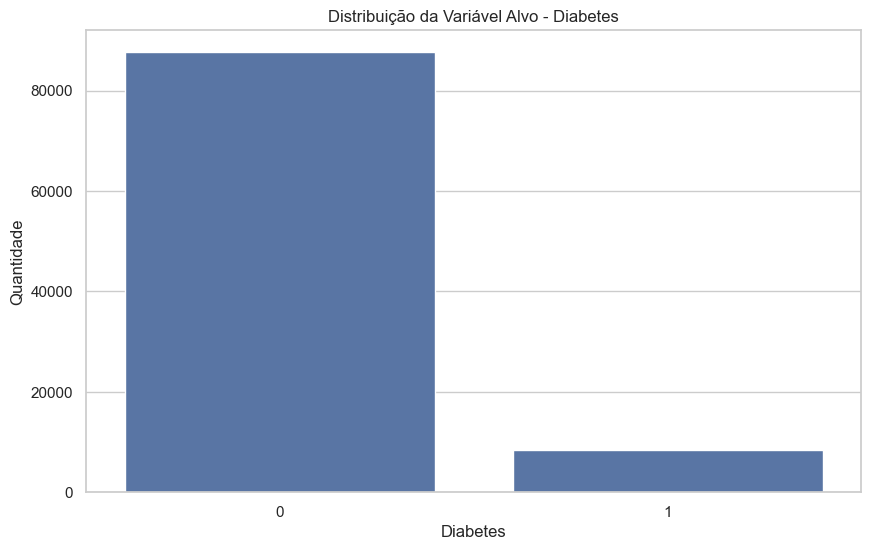

In [11]:
sns.countplot(data=df, x="diabetes")
plt.title("Distribuição da Variável Alvo - Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Quantidade")
plt.show()

## Interpretação da variável alvo

Observa-se que a base apresenta uma quantidade muito maior de pacientes sem diabetes em comparação aos pacientes diagnosticados com a doença.

Esse comportamento indica um desbalanceamento entre as classes. Em problemas de saúde, isso é comum, pois geralmente há menos casos positivos do que negativos. Por esse motivo, durante a avaliação dos modelos, métricas como **recall**, **F1-score** e **ROC-AUC** devem receber atenção especial, já que a acurácia isolada pode ser enganosa.

# 5. Análise da Idade

A idade é uma variável relevante porque o risco de diabetes pode aumentar com o passar dos anos.

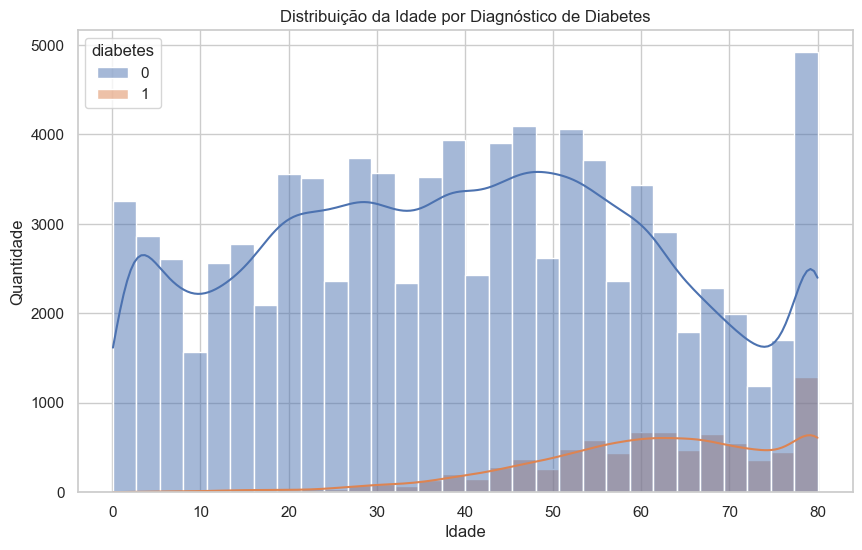

In [12]:
sns.histplot(data=df, x="age", hue="diabetes", bins=30, kde=True)
plt.title("Distribuição da Idade por Diagnóstico de Diabetes")
plt.xlabel("Idade")
plt.ylabel("Quantidade")
plt.show()

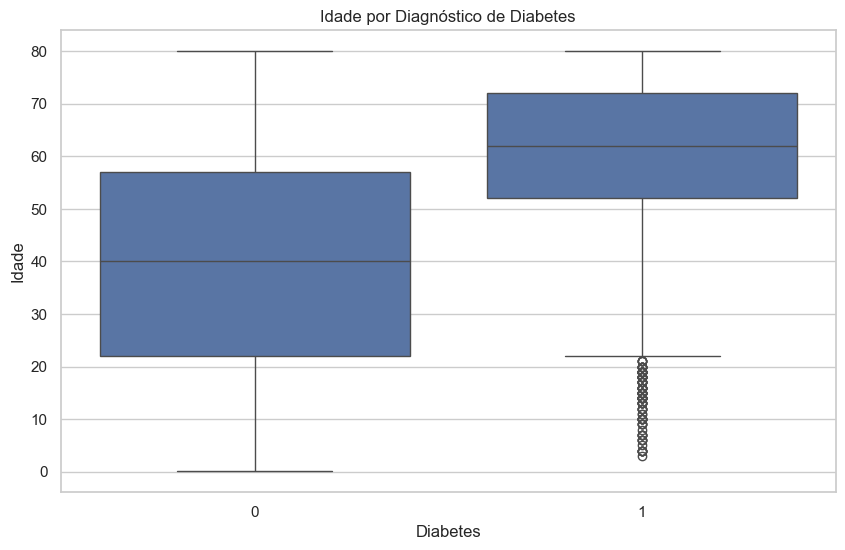

In [13]:
sns.boxplot(data=df, x="diabetes", y="age")
plt.title("Idade por Diagnóstico de Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Idade")
plt.show()

In [14]:
df.groupby("diabetes")["age"].mean()

diabetes
0    39.943229
1    60.925961
Name: age, dtype: float64

## Interpretação

A análise da idade permite observar se pacientes com diabetes apresentam uma faixa etária diferente dos pacientes sem a doença.

Caso a média de idade dos pacientes com diabetes seja maior, isso indica que a idade pode ser um fator importante para a previsão. Essa variável será mantida no modelo por representar uma característica demográfica relevante para identificar grupos com maior risco.

# 6. Análise do IMC

O Índice de Massa Corporal (IMC) é uma variável clínica importante, pois está relacionado ao excesso de peso e à obesidade, fatores frequentemente associados ao diabetes tipo 2.

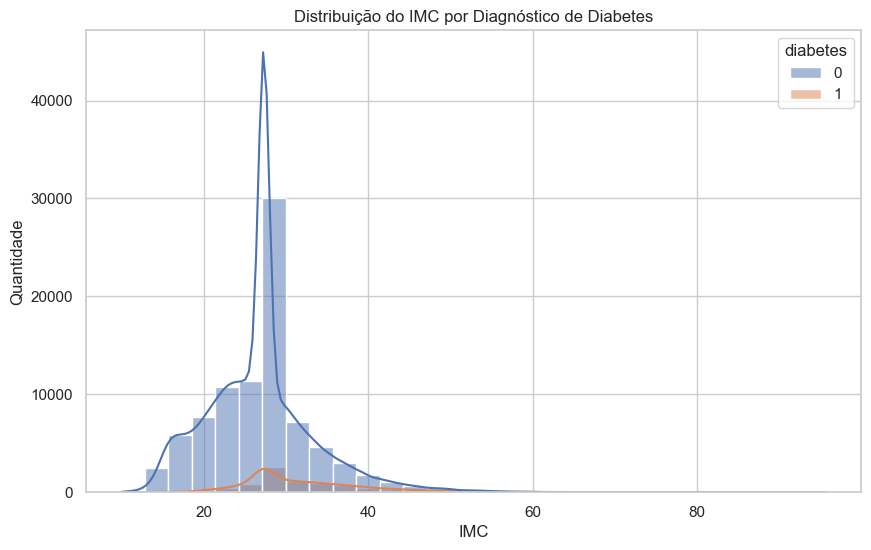

In [15]:
sns.histplot(data=df, x="bmi", hue="diabetes", bins=30, kde=True)
plt.title("Distribuição do IMC por Diagnóstico de Diabetes")
plt.xlabel("IMC")
plt.ylabel("Quantidade")
plt.show()

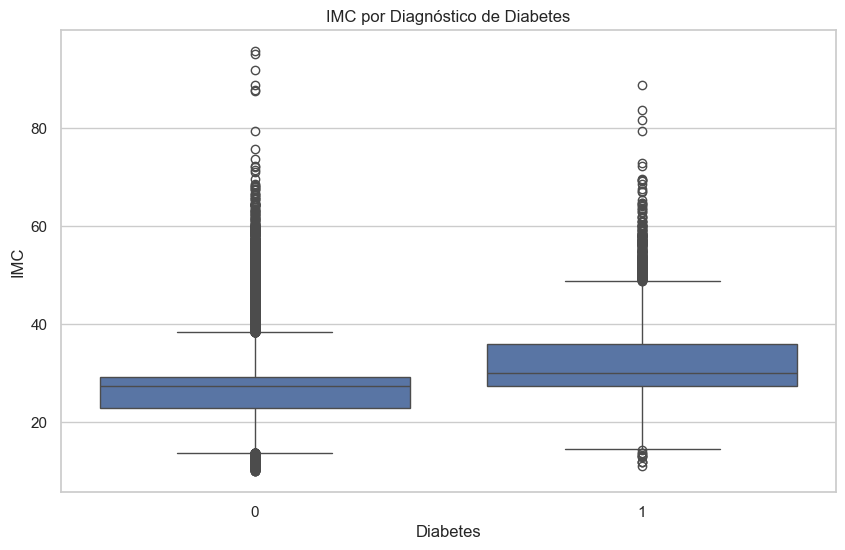

In [16]:
sns.boxplot(data=df, x="diabetes", y="bmi")
plt.title("IMC por Diagnóstico de Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("IMC")
plt.show()

In [17]:
df.groupby("diabetes")["bmi"].mean()

diabetes
0    26.869003
1    31.997755
Name: bmi, dtype: float64

## Interpretação

A comparação do IMC entre pacientes com e sem diabetes ajuda a identificar se existe associação entre excesso de peso e diagnóstico da doença.

Se pacientes diabéticos apresentarem IMC médio mais alto, isso reforça a importância dessa variável para o modelo preditivo. O IMC é relevante porque pode indicar condições metabólicas associadas ao desenvolvimento do diabetes.

# 7. Análise da Hemoglobina Glicada (HbA1c)

A hemoglobina glicada é um indicador clínico utilizado para avaliar os níveis médios de glicose no sangue ao longo do tempo.

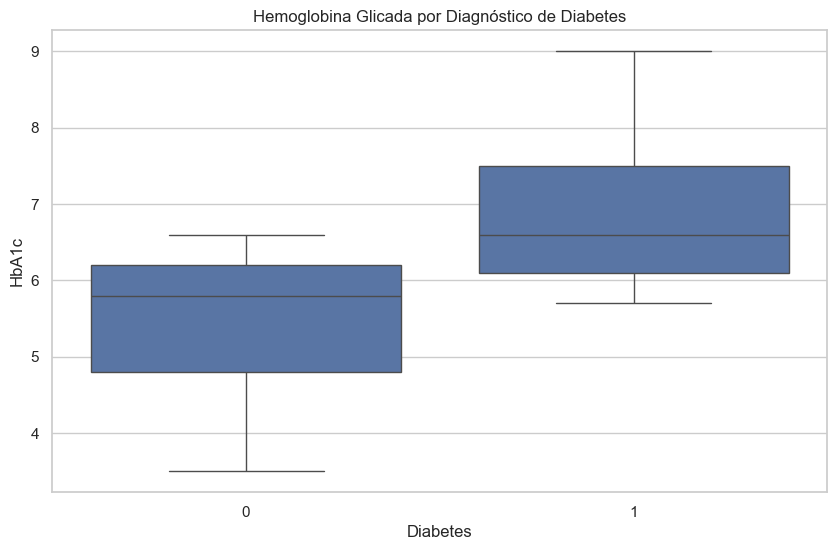

In [18]:
sns.boxplot(data=df, x="diabetes", y="HbA1c_level")
plt.title("Hemoglobina Glicada por Diagnóstico de Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("HbA1c")
plt.show()

In [19]:
df.groupby("diabetes")["HbA1c_level"].mean()

diabetes
0    5.396936
1    6.934827
Name: HbA1c_level, dtype: float64

## Interpretação da HbA1c

A hemoglobina glicada é uma das variáveis mais importantes para o problema, pois está diretamente relacionada ao controle glicêmico do paciente.

Diferenças relevantes entre os grupos indicam que essa variável pode contribuir fortemente para a identificação de pacientes com diabetes. Por ser um indicador clínico consolidado, sua presença no modelo é altamente justificável.

# 8. Análise do Nível de Glicose no Sangue

O nível de glicose no sangue é uma variável diretamente relacionada ao diagnóstico de diabetes.

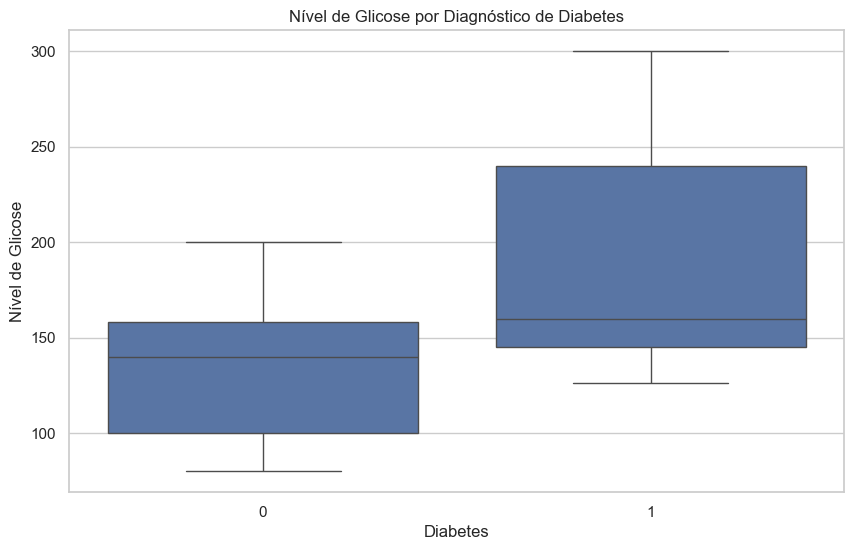

In [20]:
sns.boxplot(data=df, x="diabetes", y="blood_glucose_level")
plt.title("Nível de Glicose por Diagnóstico de Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Nível de Glicose")
plt.show()

In [21]:
df.groupby("diabetes")["blood_glucose_level"].mean()

diabetes
0    132.818489
1    194.026173
Name: blood_glucose_level, dtype: float64

## Interpretação da glicose

O nível de glicose no sangue tende a ser uma das variáveis com maior poder explicativo para a previsão de diabetes.

Quando pacientes diagnosticados com diabetes apresentam níveis médios de glicose superiores aos demais, isso evidencia a relevância dessa variável para a construção do modelo de Machine Learning.

# 9. Análise por Sexo

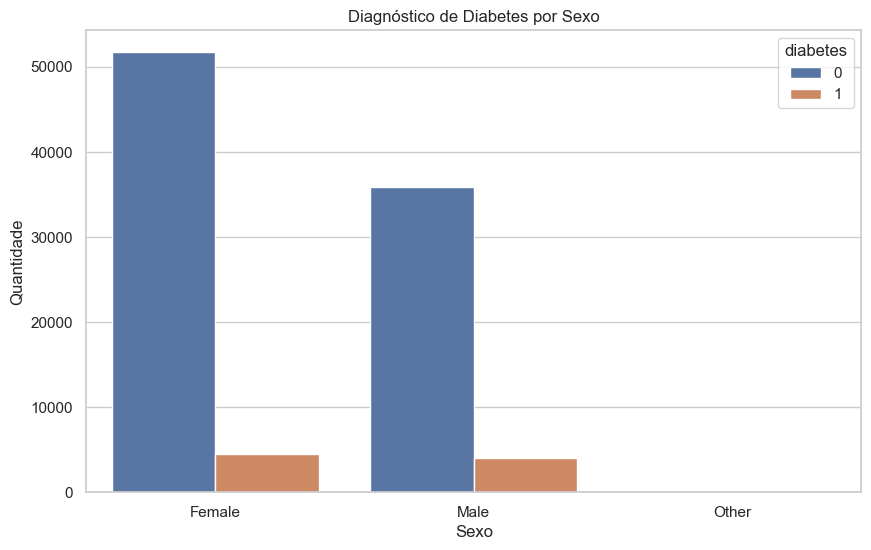

In [22]:
sns.countplot(data=df, x="gender", hue="diabetes")
plt.title("Diagnóstico de Diabetes por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Quantidade")
plt.show()

In [23]:
pd.crosstab(df["gender"], df["diabetes"], normalize="index") * 100

diabetes,0,1
gender,,
Female,92.081694,7.918306
Male,89.904171,10.095829
Other,100.000000,0.000000


## Interpretação por sexo

A análise por sexo permite verificar se existe diferença na proporção de diabetes entre os grupos. Mesmo que essa variável apresente influência menor quando comparada às variáveis clínicas, ela pode ajudar o modelo a compreender padrões demográficos presentes na base de dados.

# 10. Análise da Hipertensão

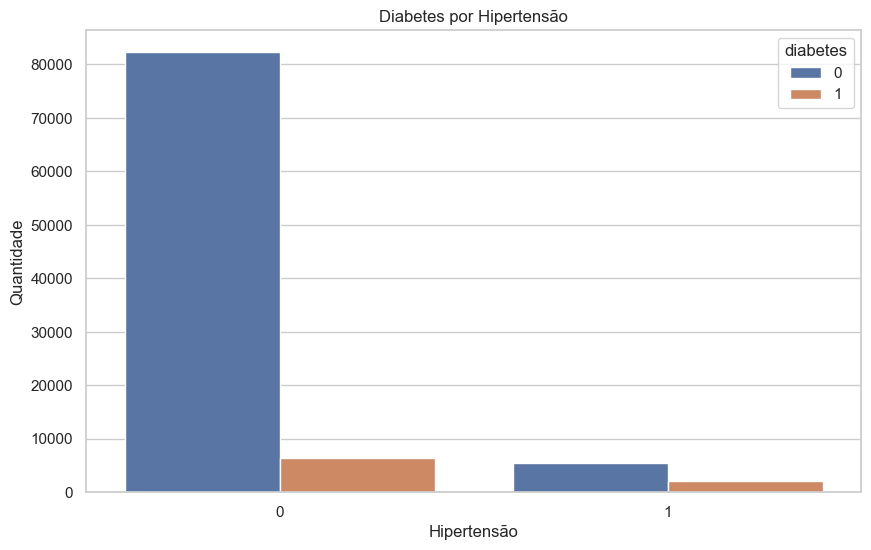

In [24]:
sns.countplot(data=df, x="hypertension", hue="diabetes")
plt.title("Diabetes por Hipertensão")
plt.xlabel("Hipertensão")
plt.ylabel("Quantidade")
plt.show()

In [25]:
pd.crosstab(df["hypertension"], df["diabetes"], normalize="index") * 100

diabetes,0,1
hypertension,,
0,92.787957,7.212043
1,72.041281,27.958719


## Interpretação da hipertensão

A análise da hipertensão permite verificar se pacientes hipertensos apresentam maior proporção de diabetes. Se o percentual de diabetes for maior entre pacientes com hipertensão, essa variável se torna relevante para a solução do problema, pois pode indicar maior risco clínico e auxiliar o modelo na identificação de pacientes vulneráveis.

# 11. Análise da Doença Cardíaca

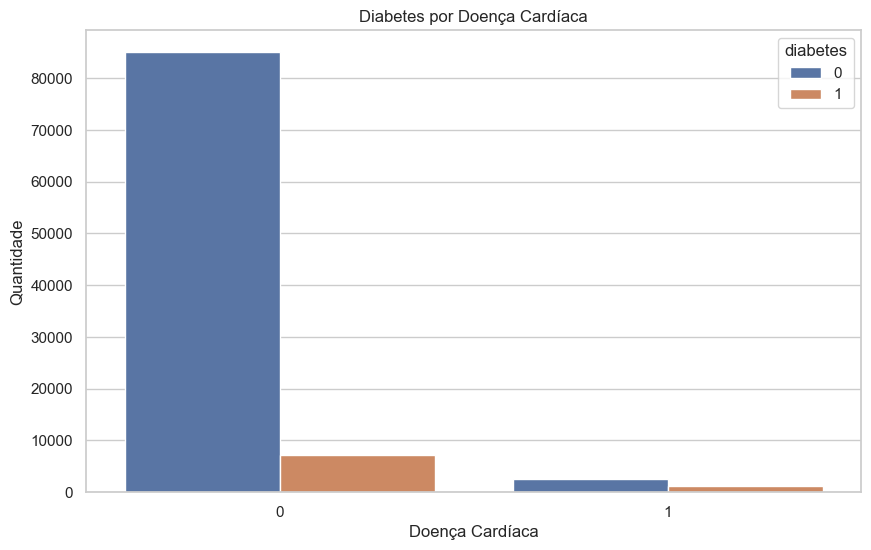

In [26]:
sns.countplot(data=df, x="heart_disease", hue="diabetes")
plt.title("Diabetes por Doença Cardíaca")
plt.xlabel("Doença Cardíaca")
plt.ylabel("Quantidade")
plt.show()

In [27]:
pd.crosstab(df["heart_disease"], df["diabetes"], normalize="index") * 100

diabetes,0,1
heart_disease,,
0,92.176572,7.823428
1,67.703288,32.296712


## Interpretação da doença cardíaca

A presença de doença cardíaca pode ser um indicativo de maior risco para diabetes. Caso os pacientes com doença cardíaca apresentem maior proporção de diabetes, essa variável se torna importante para o modelo, pois representa uma condição clínica associada ao perfil de risco do paciente.

# 12. Análise do Histórico de Tabagismo

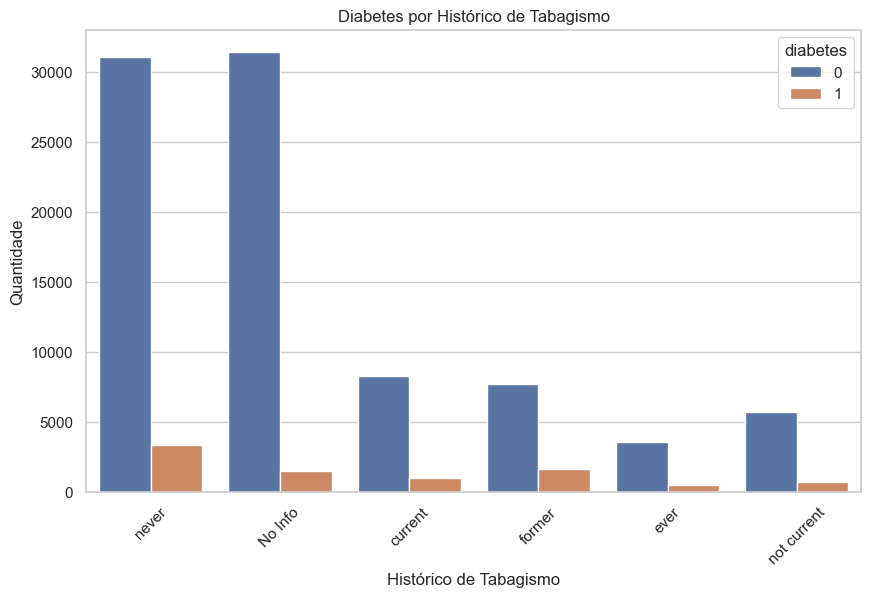

In [28]:
sns.countplot(data=df, x="smoking_history", hue="diabetes")
plt.title("Diabetes por Histórico de Tabagismo")
plt.xlabel("Histórico de Tabagismo")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.show()

In [29]:
pd.crosstab(df["smoking_history"], df["diabetes"], normalize="index") * 100

diabetes,0,1
smoking_history,,
No Info,95.606167,4.393833
current,89.692291,10.307709
ever,88.194097,11.805903
former,82.901387,17.098613
never,90.298855,9.701145
not current,89.162871,10.837129


## Interpretação do histórico de tabagismo

A análise do histórico de tabagismo permite avaliar se determinados grupos apresentam maior proporção de diabetes. Embora essa variável possa não ter o mesmo impacto de glicose ou HbA1c, ela representa um hábito de vida relevante e pode complementar a compreensão do perfil dos pacientes.

# 13. Matriz de Correlação

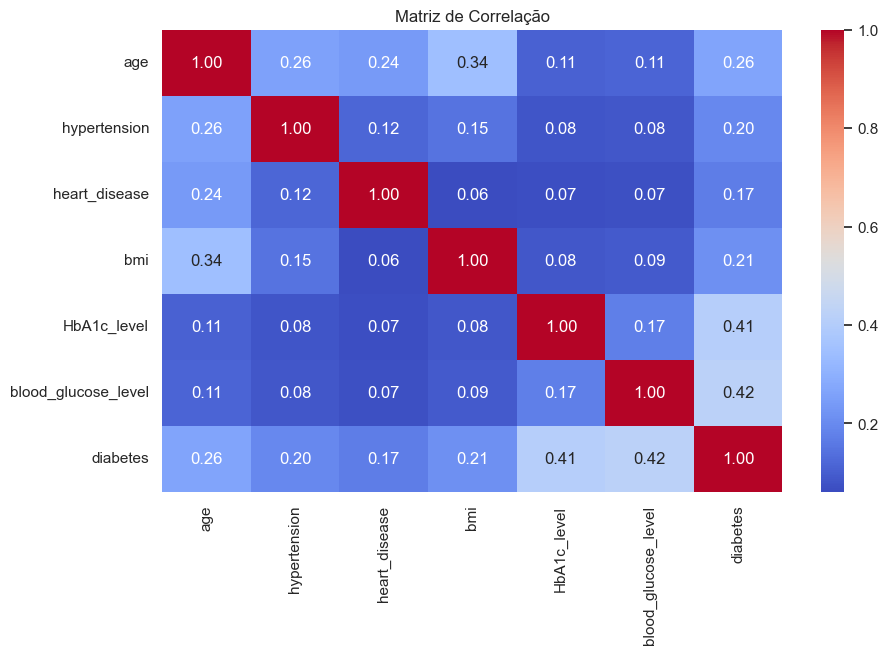

In [30]:
df_numeric = df.select_dtypes(include=["int64", "float64"])
corr = df_numeric.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

## Interpretação da matriz de correlação

A matriz de correlação ajuda a identificar quais variáveis numéricas possuem maior associação com o diagnóstico de diabetes. Espera-se que variáveis como nível de glicose, HbA1c, idade e IMC apresentem maior relação com a variável alvo. Essa análise contribui para justificar a escolha das variáveis utilizadas no modelo.

# 14. Justificativa dos Principais Pontos Escolhidos

Com base na análise exploratória, os principais pontos escolhidos para a solução do problema foram idade, IMC, hemoglobina glicada, nível de glicose, hipertensão, doença cardíaca, histórico de tabagismo e sexo.

Essas variáveis foram escolhidas porque representam características demográficas, clínicas e comportamentais relacionadas ao risco de diabetes.

As variáveis clínicas, especialmente glicose e HbA1c, possuem relação direta com o diagnóstico da doença. Já idade, IMC, hipertensão e doença cardíaca ajudam a identificar perfis de maior risco. As variáveis categóricas, como sexo e histórico de tabagismo, complementam a análise ao adicionar informações sobre o perfil do paciente.

Dessa forma, a utilização dessas variáveis contribui para construir um modelo mais completo e capaz de identificar indivíduos com maior probabilidade de apresentar diabetes.

# 15. Preparação dos Dados para Machine Learning

In [31]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

X.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,Female,80.0,0,1,never,25.19,6.6,140
1,Female,54.0,0,0,No Info,27.32,6.6,80
2,Male,28.0,0,0,never,27.32,5.7,158
3,Female,36.0,0,0,current,23.45,5.0,155
4,Male,76.0,1,1,current,20.14,4.8,155


In [32]:
variaveis_numericas = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
variaveis_categoricas = ["gender", "hypertension", "heart_disease", "smoking_history"]

print("Variáveis numéricas:", variaveis_numericas)
print("Variáveis categóricas:", variaveis_categoricas)

Variáveis numéricas: ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Variáveis categóricas: ['gender', 'hypertension', 'heart_disease', 'smoking_history']


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)

Tamanho do treino: (76916, 8)
Tamanho do teste: (19230, 8)


In [34]:
preprocessamento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variaveis_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), variaveis_categoricas)
    ]
)

## Interpretação da preparação dos dados

A separação entre treino e teste é necessária para avaliar se o modelo consegue generalizar bem para dados que não foram utilizados no treinamento. O parâmetro `stratify=y` foi utilizado para manter a proporção entre pacientes com e sem diabetes tanto no treino quanto no teste, o que é importante em bases desbalanceadas.

As variáveis numéricas foram padronizadas e as variáveis categóricas foram transformadas por meio de One-Hot Encoding, permitindo que os modelos trabalhem corretamente com os diferentes tipos de dados.

# 16. Modelo 1 — Regressão Logística

A Regressão Logística é um modelo estatístico bastante utilizado para problemas de classificação binária, como prever se um paciente possui ou não diabetes.

In [35]:
modelo_logistico = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

modelo_logistico.fit(X_train, y_train)

y_pred_log = modelo_logistico.predict(X_test)
y_prob_log = modelo_logistico.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - Regressão Logística")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Relatório de Classificação - Regressão Logística
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17534
           1       0.43      0.88      0.57      1696

    accuracy                           0.88     19230
   macro avg       0.71      0.88      0.75     19230
weighted avg       0.94      0.88      0.90     19230

ROC-AUC: 0.9600621958738924


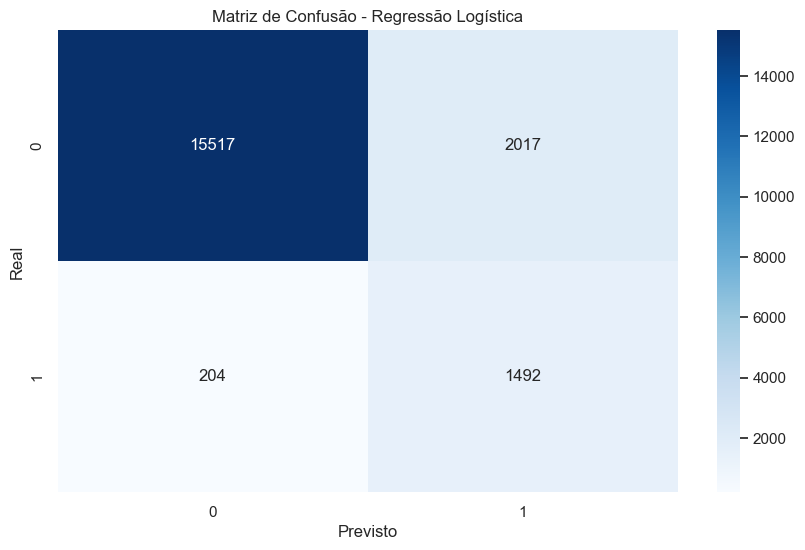

In [36]:
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão - Regressão Logística")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

## Interpretação da Regressão Logística

A Regressão Logística permite interpretar o problema de forma simples e serve como um bom modelo inicial para comparação. Como a base é desbalanceada, foi utilizado o parâmetro `class_weight="balanced"`, que ajuda o modelo a dar maior atenção à classe minoritária, ou seja, aos pacientes com diabetes.

A matriz de confusão deve ser analisada para verificar quantos pacientes com diabetes foram corretamente identificados e quantos foram classificados incorretamente.

# 17. Modelo 2 — Random Forest

O Random Forest é um modelo baseado em árvores de decisão. Ele costuma apresentar bom desempenho em problemas de classificação, pois combina várias árvores para gerar uma previsão mais robusta.

In [37]:
modelo_rf = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("modelo", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Relatório de Classificação - Random Forest
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.94      0.69      0.80      1696

    accuracy                           0.97     19230
   macro avg       0.95      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230

ROC-AUC: 0.9590490867070123


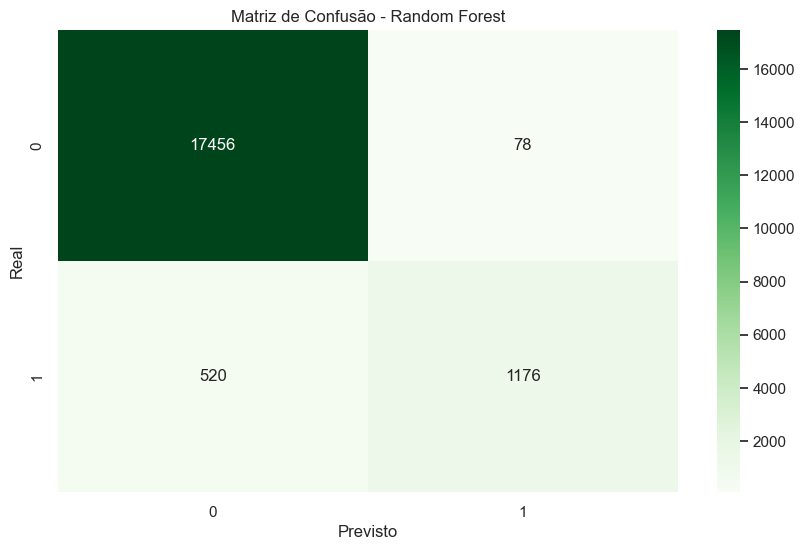

In [38]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

## Interpretação do Random Forest

O Random Forest foi utilizado por ser um modelo mais flexível e capaz de capturar relações não lineares entre as variáveis. Assim como na Regressão Logística, foi utilizado `class_weight="balanced"` para lidar com o desbalanceamento da base.

A matriz de confusão permite avaliar a quantidade de acertos e erros do modelo, especialmente na identificação dos pacientes com diabetes.

# 18. Comparação dos Modelos

In [39]:
resultados = pd.DataFrame({
    "Modelo": ["Regressão Logística", "Random Forest"],
    "Acurácia": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precisão": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

resultados

,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC-AUC
0,Regressão Logística,0.884503,0.425192,0.879717,0.573295,0.960062
1,Random Forest,0.968903,0.937799,0.693396,0.797288,0.959049


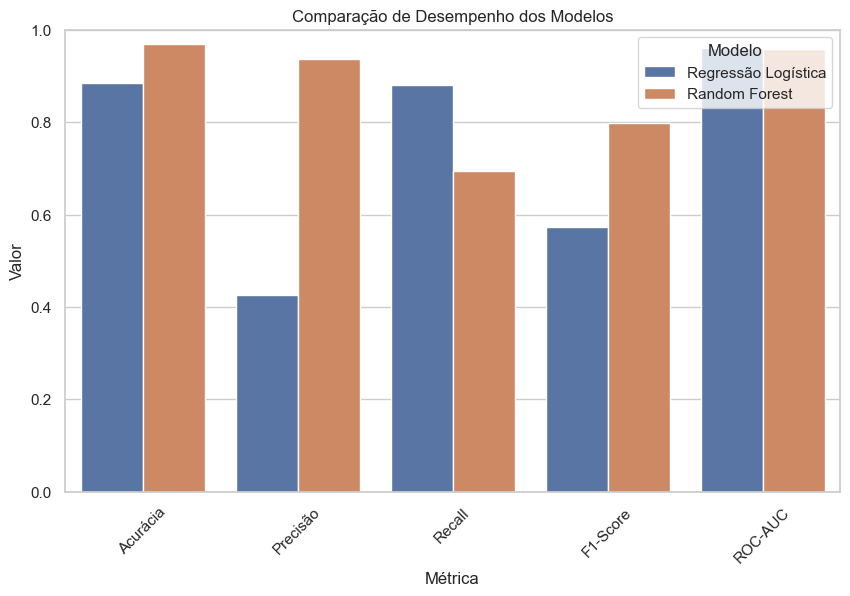

In [40]:
resultados_melt = resultados.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

sns.barplot(data=resultados_melt, x="Métrica", y="Valor", hue="Modelo")
plt.title("Comparação de Desempenho dos Modelos")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

## Interpretação da comparação dos modelos

A comparação entre os modelos deve considerar mais do que apenas a acurácia, pois a base possui desbalanceamento entre as classes.

Para este projeto, as métricas mais importantes são:

- **Recall**: indica a capacidade do modelo de identificar corretamente pacientes com diabetes;
- **F1-Score**: equilibra precisão e recall;
- **ROC-AUC**: avalia a capacidade geral do modelo de separar as classes.

O melhor modelo será aquele que apresentar bom desempenho geral, especialmente na identificação da classe positiva, que representa os pacientes com diabetes.

# 19. Curva ROC

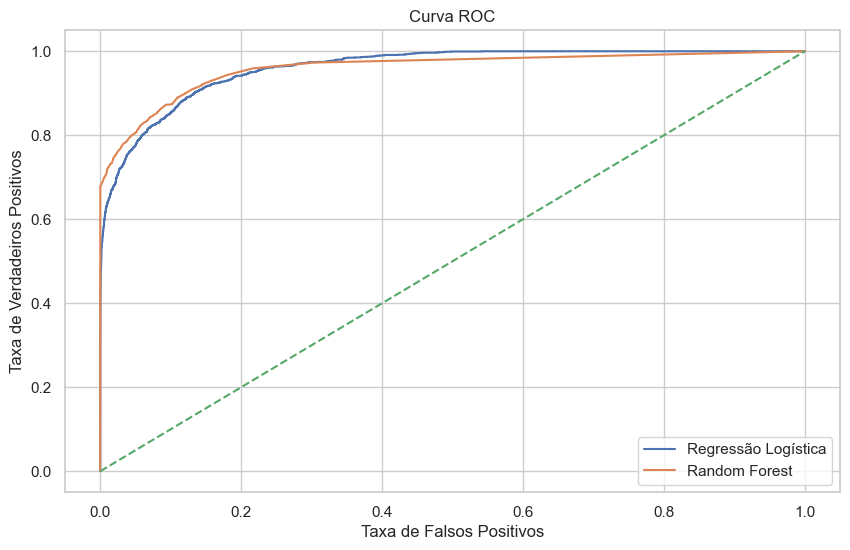

In [41]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_log, tpr_log, label="Regressão Logística")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Curva ROC")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.legend()
plt.show()

## Interpretação da Curva ROC

Quanto mais próxima a curva estiver do canto superior esquerdo, melhor é o desempenho do modelo. A curva ROC complementa a análise das métricas, pois mostra visualmente a capacidade dos modelos em separar pacientes com e sem diabetes. O modelo com maior área sob a curva tende a apresentar melhor desempenho geral.

# 20. Importância das Variáveis

In [42]:
nomes_cat = modelo_rf.named_steps["preprocessamento"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(variaveis_categoricas)

nomes_variaveis = np.concatenate([variaveis_numericas, nomes_cat])
importancias = modelo_rf.named_steps["modelo"].feature_importances_

df_importancias = pd.DataFrame({
    "Variável": nomes_variaveis,
    "Importância": importancias
}).sort_values(by="Importância", ascending=False)

df_importancias

,Variável,Importância
2,HbA1c_level,0.354408
3,blood_glucose_level,0.260260
0,age,0.183607
1,bmi,0.125841
7,hypertension_0,0.014920
8,hypertension_1,0.014797
9,heart_disease_0,0.008845
11,smoking_history_No Info,0.007321
10,heart_disease_1,0.006726
15,smoking_history_never,0.004186


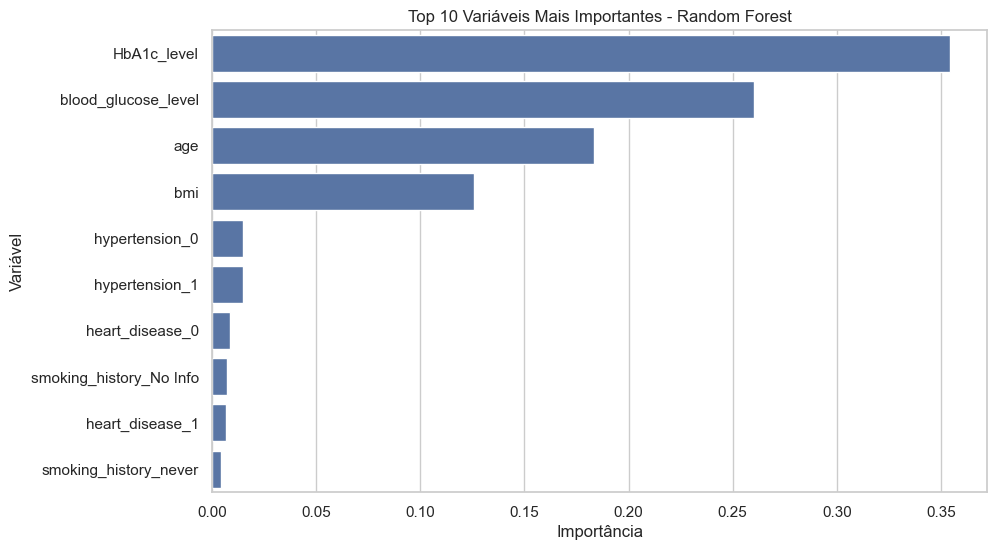

In [43]:
sns.barplot(data=df_importancias.head(10), x="Importância", y="Variável")
plt.title("Top 10 Variáveis Mais Importantes - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()

## Interpretação da importância das variáveis

A análise de importância das variáveis permite identificar quais características mais contribuíram para as previsões do modelo. Espera-se que variáveis clínicas, como HbA1c, nível de glicose, idade e IMC, apareçam entre as mais importantes, pois estão diretamente relacionadas ao diagnóstico de diabetes.

Essa etapa é importante porque ajuda a tornar o modelo mais interpretável e permite compreender quais fatores mais influenciam a previsão.

# 21. Conclusão Final

O projeto teve como objetivo construir uma solução baseada em análise de dados e Machine Learning para prever a ocorrência de diabetes.

Durante a análise exploratória, foram avaliadas variáveis demográficas, clínicas e comportamentais. Os principais fatores analisados foram idade, IMC, hemoglobina glicada, nível de glicose, hipertensão, doença cardíaca, histórico de tabagismo e sexo.

A análise indicou que variáveis clínicas apresentam grande relevância para a identificação de pacientes com diabetes, especialmente aquelas diretamente relacionadas ao controle glicêmico.

Na etapa de modelagem, foram construídos dois modelos de classificação: Regressão Logística e Random Forest. Os modelos foram avaliados por meio de métricas como acurácia, precisão, recall, F1-score, matriz de confusão e ROC-AUC.

Considerando que o problema envolve a identificação de pacientes com diabetes, métricas como recall e ROC-AUC são especialmente importantes, pois avaliam a capacidade do modelo de detectar corretamente casos positivos.

Dessa forma, o uso de dados e Machine Learning mostrou-se relevante para apoiar a detecção precoce do diabetes e auxiliar profissionais da saúde na tomada de decisão baseada em evidências.